In [2]:
# -------------------------------------------------------------
# LOAD DATA AGAIN (If kernel was restarted)
# -------------------------------------------------------------
import pandas as pd

sales = pd.read_csv("Sales.csv")
customers = pd.read_csv("Customers.csv")
models = pd.read_csv("MobileModels.csv")
shops = pd.read_csv("ShopLocations.csv")
offers = pd.read_csv("Offers.csv")
stocks = pd.read_csv("Stocks.csv")

print("Datasets loaded successfully!")


Datasets loaded successfully!


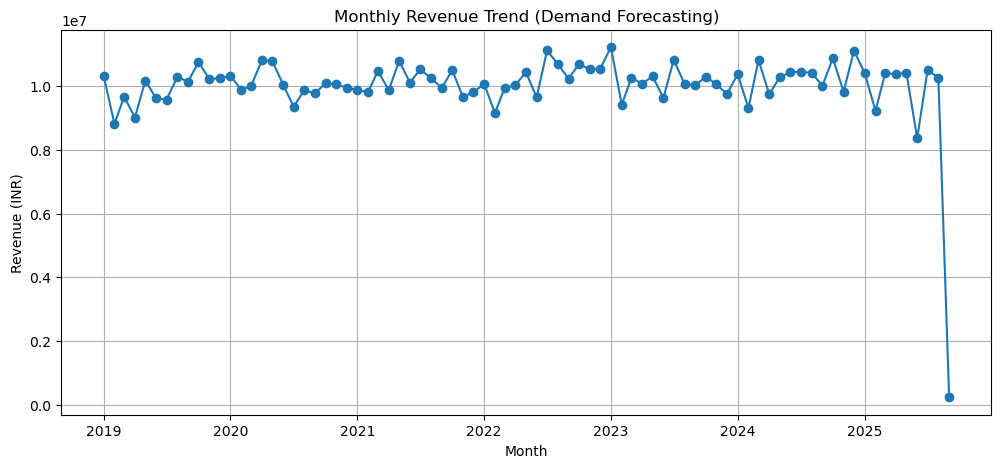

In [3]:
# 11.4 DEMAND FORECASTING — Monthly Sales Trend
import pandas as pd
import matplotlib.pyplot as plt

# Ensure date format exists
sales["sale_date"] = pd.to_datetime(sales["sale_date"])

# Monthly revenue aggregation
monthly_sales = sales.groupby(sales["sale_date"].dt.to_period("M"))["final_price"].sum()
monthly_sales.index = monthly_sales.index.to_timestamp()

plt.figure(figsize=(12,5))
plt.plot(monthly_sales, marker="o")
plt.title("Monthly Revenue Trend (Demand Forecasting)")
plt.xlabel("Month")
plt.ylabel("Revenue (INR)")
plt.grid(True)
plt.show()


Monthly Revenue Data:


sale_date
2019-01-01    12864509.0
2019-02-01    11046718.0
2019-03-01    11790564.0
2019-04-01    11383080.0
2019-05-01    13353268.0
Freq: MS, Name: revenue, dtype: float64

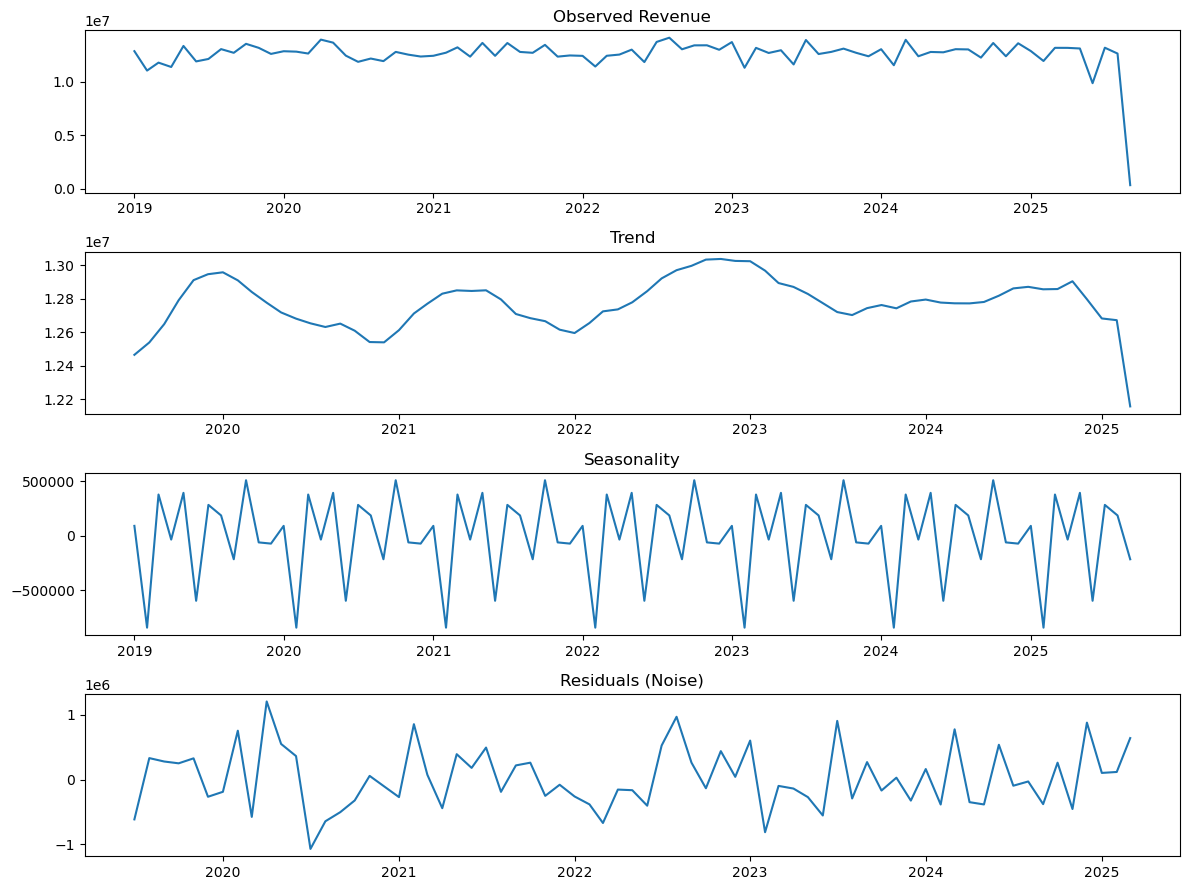

In [4]:
# 11.4 ADVANCED DEMAND FORECASTING — Seasonal Decomposition

import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# 1. LOAD SALES DATA
# (If already loaded above, you can skip this)
sales = pd.read_csv("sales.csv")

# Ensure date column exists
sales["sale_date"] = pd.to_datetime(sales["sale_date"], errors='coerce')

# Drop invalid dates
sales = sales.dropna(subset=["sale_date"])

# 2. Monthly Aggregation of Revenue
sales["revenue"] = sales["final_price"] * sales["quantity"]

monthly = (
    sales.groupby(sales["sale_date"].dt.to_period("M"))["revenue"]
    .sum()
    .to_timestamp()
)

print("Monthly Revenue Data:")
display(monthly.head())

# 3. Seasonal Decomposition
decomposition = seasonal_decompose(monthly, model='additive', period=12)

# 4. Plot Full Decomposition
plt.figure(figsize=(12, 9))

plt.subplot(411)
plt.plot(decomposition.observed)
plt.title("Observed Revenue")

plt.subplot(412)
plt.plot(decomposition.trend)
plt.title("Trend")

plt.subplot(413)
plt.plot(decomposition.seasonal)
plt.title("Seasonality")

plt.subplot(414)
plt.plot(decomposition.resid)
plt.title("Residuals (Noise)")

plt.tight_layout()
plt.show()
